# 🚢 Hydrostatic & Stability Analysis Engine  
### From Offset Table to Stability Insights

---

## 🔍 Problem Context

In naval architecture, hydrostatic and stability calculations are fundamental to assessing whether a vessel is safe, efficient, and operationally viable.

However:
- Raw offset tables are not directly interpretable
- Numerical integration must be applied carefully
- Stability behavior requires multi-stage computation (KB, BM, GM, GZ)

---

## 🎯 Objective

To build a **modular computational pipeline** that:

- Parses real-world ship data (Excel offset tables)
- Computes hydrostatic properties using numerical integration
- Generates stability curves (GZ vs Heel Angle)
- Validates results using engineering approximations

---

## 🧠 Approach (System Thinking)

Instead of isolated calculations, this solution is designed as:

> **A pipeline where each module feeds the next, ensuring traceability and validation at every step**

---

## 🏗️ Pipeline Overview

1. Data Parsing  
2. Geometry Reconstruction  
3. Numerical Integration  
4. Hydrostatics Calculation  
5. Stability Analysis  
6. Visualization + Validation  

---

In [88]:
# SETUP: Install dependencies (run once)
import numpy as np
import pandas as pd
from scipy.integrate import simpson, trapezoid
import matplotlib.pyplot as plt
from pathlib import Path

SOLUTION FLOW ---- > **Excel → Parsing → Geometry → Integration → Hydrostatics → Stability → Visualization → Validation**

In [89]:
# MODULE 1: NUMERICAL INTEGRATION
# ============================================================================

class NumericalIntegrator:
    """Simpson's rule for 1D and 2D integration (handles non-uniform spacing)."""

    @staticmethod
    def simpson_1d(x, y):
        """Apply Simpson's rule for 1D integration."""
        return simpson(y, x=x)

    @staticmethod
    def simpson_2d(x, y, z_matrix):
        """Apply Simpson's rule in 2D (iterate approach)."""
        result_along_x = np.zeros(len(x))
        for i in range(len(x)):
            result_along_x[i] = simpson(z_matrix[i, :], x=y)
        return simpson(result_along_x, x=x)

# 📐 Module 1: Numerical Integration

---

## 🔍 Why Integration?

Hydrostatic calculations rely on integrating:
- sectional areas → volume
- moments → centers of buoyancy

Since real ship data is **discrete**, numerical methods are required.

---

## ⚙️ Methods Used

### 1. Simpson’s Rule
- Higher accuracy
- Used for primary calculations

### 2. Trapezoidal Rule
- Simpler approximation
- Used for validation

---

## 🧠 Design Decision

We use:
- **Simpson (primary)** → accuracy
- **Trapezoidal (secondary)** → cross-verification

This ensures:
✔ Reliability  
✔ Transparency  
✔ Engineering validity  

---

In [90]:
# MODULE 2: GEOMETRY ENGINE
# ============================================================================

class GeometryEngine:
    """Computes sectional areas and waterplane properties from offset table."""

    def __init__(self, stations, waterlines, offset_table):
        self.stations = np.array(stations)
        self.waterlines = np.array(waterlines)
        self.offset_table = np.array(offset_table)
        self.integrator = NumericalIntegrator()

    def compute_sectional_area(self, station_idx, draft):
        """Compute submerged sectional area at given station."""
        half_breadths = self.offset_table[:, station_idx]
        full_breadths = 2.0 * half_breadths

        wl_mask = self.waterlines <= draft
        wl_subset = self.waterlines[wl_mask]
        breadth_subset = full_breadths[wl_mask]

        if len(wl_subset) < 2:
            return 0.0

        return self.integrator.simpson_1d(wl_subset, breadth_subset)

    def compute_all_sectional_areas(self, draft):
        """Compute sectional areas for all stations."""
        areas = np.zeros(len(self.stations))
        for i in range(len(self.stations)):
            areas[i] = self.compute_sectional_area(i, draft)
        return areas

    def compute_waterplane_area(self, draft):
        """Compute waterplane area at given draft."""
        idx = np.searchsorted(self.waterlines, draft)
        if idx >= len(self.waterlines):
            idx = len(self.waterlines) - 1
        if idx == 0:
            idx = 1

        z1, z2 = self.waterlines[idx - 1], self.waterlines[idx]
        b1, b2 = self.offset_table[idx - 1, :], self.offset_table[idx, :]

        if abs(z2 - z1) > 1e-6:
            frac = (draft - z1) / (z2 - z1)
            half_breadths = b1 + frac * (b2 - b1)
        else:
            half_breadths = b1

        full_breadths = 2.0 * half_breadths
        return self.integrator.simpson_1d(self.stations, full_breadths)

# 🧱 Module 2: Geometry Engine

---

## 🔍 Role of Geometry Engine

Transforms raw offset data into:
- sectional areas
- waterplane areas
- geometric representations

---

## ⚙️ Key Computations

- Half-breadths → Full breadths  
- Sectional area via integration  
- Waterplane extraction at given draft  

---

## ⚠️ Assumptions

- Symmetry about centerline  
- Smooth hull interpolation  
- Discrete stations approximate continuous hull  

---

## 🧠 Insight

> Geometry is not just preprocessing — it directly influences accuracy of hydrostatic outputs.

---

In [91]:
# MODULE -3 parser_solution.py
# solution parser for HydroHackathon Excel format
# Tested against: 69ec3fe06117b_HydroHackathon_PS_File.xlsx

import pandas as pd
import numpy as np


class OffsetTableParser:
    """
    Parses HydroHackathon Excel format:
    - Sheet 1 "Main Particulars": Ship dimensions + waterline definitions
    - Sheet 2 "Offset data": Station coordinates + half-breadth table
    """

    def __init__(self):
        """Initialize parser (no hardcoded paths)."""
        self.offset_table = None
        self.stations = None
        self.waterlines = None
        self.loa = None
        self.length = None
        self.breadth = None
        self.draft = None
        self.depth = None
        self.cb = None

    def load_from_xlsx(self, filepath):
        """
        Load and parse HydroHackathon Excel file.

        Args:
            filepath: Path to Excel file with sheets "Main Particulars" and "Offset data"

        Returns:
            (offset_table, stations, waterlines) tuple

        Raises:
            ValueError: If required sheets/data missing or invalid
        """
        try:
            df_main = pd.read_excel(filepath, sheet_name="Main Particulars", header=None)
            df_offset = pd.read_excel(filepath, sheet_name="Offset data", header=None)
        except Exception as e:
            raise ValueError(f"Failed to read Excel sheets: {e}")

        # ==================== PARSE MAIN PARTICULARS ====================

        # Row 1: LOA (Length Overall)
        self.loa = float(df_main.iloc[1, 2])
        if self.loa <= 0:
            raise ValueError(f"Invalid LOA: {self.loa}")

        # Row 2: Breadth
        self.breadth = float(df_main.iloc[2, 2])
        if self.breadth <= 0:
            raise ValueError(f"Invalid Breadth: {self.breadth}")

        # Row 3: Design Draft
        self.draft = float(df_main.iloc[3, 2])
        if self.draft <= 0:
            raise ValueError(f"Invalid Draft: {self.draft}")

        # Row 4: Depth
        self.depth = float(df_main.iloc[4, 2])

        # Row 5: Block Coefficient
        self.cb = float(df_main.iloc[5, 2])
        if not (0.5 <= self.cb <= 0.95):
            raise ValueError(f"Block coefficient out of range: {self.cb}")

        # Row 11: Waterline heights (explicit Z-coordinates)
        # Format: Row 11, Cols 2-11 contain explicit heights (10 waterlines)
        waterline_heights_raw = df_main.iloc[11, 2:12].dropna().values.astype(float)
        if len(waterline_heights_raw) != 10:
            raise ValueError(f"Expected 10 waterlines, found {len(waterline_heights_raw)}")

        self.waterlines = waterline_heights_raw

        print("✓ Main Particulars loaded:")
        print(f"  LOA: {self.loa:.2f} m | Breadth: {self.breadth:.2f} m | Draft: {self.draft:.2f} m")
        print(f"  Waterlines: {len(self.waterlines)} levels from {self.waterlines[0]:.3f}m to {self.waterlines[-1]:.3f}m")

        # ==================== PARSE OFFSET DATA ====================

        # Row 3: Station coordinates (x-positions along ship)
        stations_raw = df_offset.iloc[3, 3:].dropna().values.astype(float)
        self.stations = stations_raw

        if len(self.stations) == 0:
            raise ValueError("No station coordinates found")

        # Rows 5-15: Half-breadth table
        # Row 5:  WL at 0 (keel)
        # Row 6:  WL A (first waterline)
        # Rows 7-14: WL B through K
        # Shape: 11 rows (0, A-K) × 23 columns (if 23 stations)

        offset_start_row = 5
        offset_end_row = 16  # 11 rows (0, A-K)
        offset_start_col = 3
        offset_end_col = offset_start_col + len(self.stations)

        try:
            offset_table_raw = df_offset.iloc[offset_start_row:offset_end_row, offset_start_col:offset_end_col]
            self.offset_table = offset_table_raw.values.astype(float)
        except Exception as e:
            raise ValueError(f"Failed to extract offset table: {e}")

        # Offset table has 11 rows: [z=0, A, B, C, D, E, F, G, H, J, K]
        # Waterlines array has 10 entries: [A, B, C, D, E, F, G, H, J, K]
        # Prepend z=0 to waterlines for consistency with offset table rows
        self.waterlines_with_keel = np.concatenate([[0.0], self.waterlines])

        if self.offset_table.shape[0] != len(self.waterlines_with_keel):
            raise ValueError(
                f"Offset table rows {self.offset_table.shape[0]} != waterlines (with keel) {len(self.waterlines_with_keel)}"
            )

        if self.offset_table.shape[1] != len(self.stations):
            raise ValueError(
                f"Offset table cols {self.offset_table.shape[1]} != stations {len(self.stations)}"
            )

        # Validation: Check for invalid data
        if (self.offset_table < -100).any() or (self.offset_table > 100).any():
            raise ValueError("Offset table contains unrealistic values (>100m half-breadths)")

        # Update waterlines to include keel for computation
        self.waterlines = self.waterlines_with_keel

        print(f"✓ Offset Data loaded:")
        print(f"  Stations: {len(self.stations)} locations from {self.stations[0]:.2f}m to {self.stations[-1]:.2f}m")
        print(f"  Station spacing: {np.mean(np.diff(self.stations)):.3f}m (non-uniform)")
        print(f"  Offset table shape: {self.offset_table.shape[0]} waterlines × {self.offset_table.shape[1]} stations")

        # Additional validation: Check monotonicity
        self._validate_geometry()

        print("✓ All validations passed\n")

        return self.offset_table, self.stations, self.waterlines

    def _validate_geometry(self):
        """
        Perform sanity checks on loaded geometry.
        """
        # Check 1: Offset table should have zeros at bow/stern
        first_station_max = np.max(np.abs(self.offset_table[:, 0]))
        last_station_max = np.max(np.abs(self.offset_table[:, -1]))

        if first_station_max > 5.0 or last_station_max > 5.0:
            print(f"  ⚠ Bow/stern breadths larger than expected:")
            print(f"    First station max: {first_station_max:.2f}m")
            print(f"    Last station max: {last_station_max:.2f}m")

        # Check 2: Waterlines should increase monotonically
        if not np.all(np.diff(self.waterlines) > 0):
            raise ValueError("Waterline heights not monotonically increasing")

        # Check 3: Maximum breadth should be near LOA/2 (typical for ships)
        max_breadth_in_table = np.max(self.offset_table) * 2  # Full breadth
        if max_breadth_in_table > self.breadth * 1.1:
            raise ValueError(
                f"Max breadth in table ({max_breadth_in_table:.2f}m) exceeds registered breadth ({self.breadth}m)"
            )

        # Check 4: Draft in offset table should match design draft
        if abs(self.waterlines[-1] - self.draft) > 0.01:
            print(f"  ⚠ Last waterline ({self.waterlines[-1]:.3f}m) != design draft ({self.draft}m)")

    def get_principal_dimensions(self):
        """Return ship's principal dimensions."""
        return {
            'LOA': self.loa,
            'Breadth': self.breadth,
            'Draft': self.draft,
            'Depth': self.depth,
            'CB': self.cb,
            'Num_Stations': len(self.stations),
            'Num_Waterlines': len(self.waterlines),
        }

    def get_sectional_profile(self, station_idx):
        """
        Extract sectional profile (half-breadths) at given station.

        Args:
            station_idx: Index of station (0 to num_stations-1)

        Returns:
            (waterlines, half_breadths) tuple
        """
        if not (0 <= station_idx < len(self.stations)):
            raise IndexError(f"Station index {station_idx} out of range")

        return self.waterlines, self.offset_table[:, station_idx]

# 📂 Module 3: Data Parsing (Excel → Structured Data)

---

## 🔍 Input Structure

The Excel file contains:

- Ship dimensions (LOA, Breadth, Draft, CB)
- Waterline heights
- Offset table (stations × half-breadths)

---

## ⚙️ Responsibilities

- Extract principal dimensions  
- Validate monotonic waterlines  
- Construct structured arrays for computation  

---

## 🧠 Engineering Checks

✔ Waterlines must increase monotonically  
✔ Maximum breadth sanity check  
✔ Draft consistency verification  

---

## ⚠️ Why This Matters

Bad input → wrong hydrostatics → unsafe conclusions  

So parser acts as:
> **First validation layer of the system**

---

In [92]:
# module -04 stability.py
# Stability analysis and GZ curve generation
# Compatible with HydroHackathon Phase 1

import numpy as np
from scipy.integrate import trapezoid


class StabilityAnalyzer:
    """
    Computes stability curves (GZ) for given loading conditions.
    """

    def __init__(self, hydrostatics_calc, kg):
        """
        Args:
            hydrostatics_calc: HydrostaticsCalculator instance
            kg: Ship center of gravity (m from keel)
        """
        self.hydro = hydrostatics_calc
        self.kg = kg

    def compute_gz_curve(self, draft, heel_angles=None):
        """
        Compute GZ (righting arm) across range of heel angles.

        Simplified approach:
        GZ ≈ (KB + BM - KG) · sin(θ) for small angles
        With empirical reduction for larger angles.

        Args:
            draft: Design draft (m)
            heel_angles: Array of heel angles in degrees (default 0 to 90 in 2.5° steps)

        Returns:
            GZ values (m) at each heel angle
        """
        if heel_angles is None:
            heel_angles = np.linspace(0, 90, 37)

        heel_angles = np.asarray(heel_angles)
        gz_curve = np.zeros(len(heel_angles))
        gm = self.hydro.compute_gm(draft, self.kg)

        for i, theta_deg in enumerate(heel_angles):
            theta_rad = np.radians(theta_deg)

            # Small-angle formula
            if theta_deg <= 30:
                gz = gm * np.sin(theta_rad)
            else:
                # Large-angle approximation with reduction
                # GZ decreases as metacentric radius shifts
                gz_small = gm * np.sin(theta_rad)

                # Empirical reduction factor
                # Heeling moment increases faster than linear for large angles
                reduction = 1.0 - 0.0015 * (theta_deg - 30) ** 1.5
                gz = gz_small * reduction

            gz_curve[i] = max(gz, 0.0)  # Cannot be negative (capsizes)

        return gz_curve

    def stability_metrics(self, draft, heel_angles=None):
        """
        Compute stability metrics from GZ curve.

        Args:
            draft: Design draft (m)
            heel_angles: Array of heel angles (default 0 to 90)

        Returns:
            Dictionary with stability metrics
        """
        if heel_angles is None:
            heel_angles = np.linspace(0, 90, 37)

        heel_angles = np.asarray(heel_angles)
        gz_curve = self.compute_gz_curve(draft, heel_angles)
        gm = self.hydro.compute_gm(draft, self.kg)

        # Angle of vanishing stability (where GZ = 0)
        # For very stable ships, GZ may never reach zero in tested range
        min_gz = np.min(gz_curve)
        if min_gz >= 0:
            # Ship doesn't capsize in tested range - very stable
            avs = 90.0  # Beyond tested range
        else:
            # Find where curve crosses zero
            idx = np.where(gz_curve <= 0)[0]
            if len(idx) > 0:
                avs = heel_angles[idx[0]]
            else:
                avs = 90.0

        # Maximum GZ
        max_gz = np.max(gz_curve)
        angle_at_max = heel_angles[np.argmax(gz_curve)]

        # Area under GZ curve (stability reserve)
        # Integrate using trapezoidal rule
        heel_rad = np.radians(heel_angles)
        area_under_gz = trapezoid(gz_curve, heel_rad)

        metrics = {
            'gm': gm,
            'max_gz': max_gz,
            'angle_at_max_gz': angle_at_max,
            'angle_of_vanishing_stability': avs,
            'area_under_gz_curve': area_under_gz
        }

        return metrics

# ⚖️ Module 5: Stability Analysis (GZ Curve)

---

## 🔍 What is GZ?

GZ (Righting Arm) indicates:
> Ability of ship to return to upright position

---

## 📈 Computation Strategy

- Small angles → linear approximation (GM * sinθ)
- Larger angles → geometric + nonlinear behavior

---

## 📊 Metrics Extracted

- GM → Initial stability  
- Max GZ → Peak restoring ability  
- Angle at Max GZ  
- AVS (Angle of Vanishing Stability)  
- Area under GZ curve  

---

## 🧠 Interpretation

✔ GM > 0 → Stable at small angles  
✔ Large AVS → Better survivability  

---

## 🎯 Insight

> Stability is not a single number — it is a curve-driven behavior

---

In [93]:
# MODULE -05 HYDROSTATICS CALCULATOR
# ============================================================================

class HydrostaticsCalculator:
    """Computes hydrostatic parameters (KB, BM, GM, LCB, LCF)."""

    def __init__(self, geometry_engine, fluid_density=1025):
        self.geo = geometry_engine
        self.rho = fluid_density
        self.integrator = NumericalIntegrator()

    def compute_displacement(self, draft):
        """Displacement (volume of underwater hull)."""
        sectional_areas = self.geo.compute_all_sectional_areas(draft)
        return self.integrator.simpson_1d(self.geo.stations, sectional_areas)

    def compute_kb(self, draft):
        """KB: vertical distance from keel to center of buoyancy."""
        z_centroids = np.zeros(len(self.geo.stations))

        for i in range(len(self.geo.stations)):
            half_breadths = self.geo.offset_table[:, i]
            full_breadths = 2.0 * half_breadths

            wl_mask = self.geo.waterlines <= draft
            wl_subset = self.geo.waterlines[wl_mask]
            breadth_subset = full_breadths[wl_mask]

            if len(wl_subset) < 2:
                z_centroids[i] = 0.0
                continue

            moment = self.integrator.simpson_1d(wl_subset, breadth_subset * wl_subset)
            area = self.integrator.simpson_1d(wl_subset, breadth_subset)
            z_centroids[i] = moment / area if area > 1e-6 else 0.0

        sectional_areas = self.geo.compute_all_sectional_areas(draft)
        moment_z = self.integrator.simpson_1d(self.geo.stations, z_centroids * sectional_areas)
        displacement = self.compute_displacement(draft)

        return moment_z / displacement if displacement > 1e-6 else 0.0

    def compute_lcb(self, draft):
        """LCB: longitudinal center of buoyancy."""
        sectional_areas = self.geo.compute_all_sectional_areas(draft)
        moment_x = self.integrator.simpson_1d(self.geo.stations, self.geo.stations * sectional_areas)
        displacement = self.compute_displacement(draft)
        return moment_x / displacement if displacement > 1e-6 else 0.0

    def compute_bm(self, draft):
        """BM: metacentric radius."""
        idx = np.searchsorted(self.geo.waterlines, draft)
        if idx >= len(self.geo.waterlines):
            idx = len(self.geo.waterlines) - 1

        half_breadths = self.geo.offset_table[idx, :]
        full_breadths = 2.0 * half_breadths
        b_max = np.max(full_breadths)

        L = np.max(self.geo.stations) - np.min(self.geo.stations)
        I = (b_max ** 3 * L) / 12.0

        displacement = self.compute_displacement(draft)
        return I / displacement if displacement > 1e-6 else 0.0

    def compute_gm(self, draft, kg):
        """GM: metacentric height."""
        kb = self.compute_kb(draft)
        bm = self.compute_bm(draft)
        return kb + bm - kg

    def compute_lcf(self, draft):
        """LCF: longitudinal center of flotation."""
        idx = np.searchsorted(self.geo.waterlines, draft)
        if idx >= len(self.geo.waterlines):
            idx = len(self.geo.waterlines) - 1

        half_breadths = self.geo.offset_table[idx, :]
        full_breadths = 2.0 * half_breadths

        moment_x = self.integrator.simpson_1d(self.geo.stations, self.geo.stations * full_breadths)
        aw = self.compute_waterplane_area(draft)

        return moment_x / aw if aw > 1e-6 else 0.0

    def compute_waterplane_area(self, draft):
        return self.geo.compute_waterplane_area(draft)

# ⚓ Module 4: Hydrostatics Calculator

---

## 🔍 What is Computed?

- Displacement Volume  
- KB (Center of Buoyancy)  
- BM (Metacentric Radius)  
- GM (Metacentric Height)  
- LCB / LCF  

---

## 🧠 Core Idea

Hydrostatics =  
> Geometry + Integration + Fluid Physics

---

## ⚙️ Key Relations

- Volume → ∫ sectional areas  
- KB → centroid of submerged volume  
- BM → I / V  

---

## ⚠️ Assumptions

- Constant fluid density  
- Static equilibrium  
- No dynamic effects  

---

## 🎯 Outcome

Provides **foundation for stability analysis**

---

In [94]:
# MODULE 06: STABILITY ANALYZER
# ============================================================================

class StabilityAnalyzer:
    """Computes GZ curve and stability metrics."""

    def __init__(self, hydrostatics_calc, kg):
        self.hydro = hydrostatics_calc
        self.kg = kg

    def compute_gz_curve(self, draft, heel_angles=None):
        """Compute GZ (righting arm) across range of heel angles."""
        if heel_angles is None:
            heel_angles = np.linspace(0, 90, 37)

        heel_angles = np.asarray(heel_angles)
        gz_curve = np.zeros(len(heel_angles))
        gm = self.hydro.compute_gm(draft, self.kg)

        for i, theta_deg in enumerate(heel_angles):
            theta_rad = np.radians(theta_deg)

            if theta_deg <= 30:
                gz = gm * np.sin(theta_rad)
            else:
                gz_small = gm * np.sin(theta_rad)
                reduction = 1.0 - 0.0015 * (theta_deg - 30) ** 1.5
                gz = gz_small * reduction

            gz_curve[i] = max(gz, 0.0)

        return gz_curve

    def stability_metrics(self, draft, heel_angles=None):
        """Compute stability metrics from GZ curve."""
        if heel_angles is None:
            heel_angles = np.linspace(0, 90, 37)

        heel_angles = np.asarray(heel_angles)
        gz_curve = self.compute_gz_curve(draft, heel_angles)
        gm = self.hydro.compute_gm(draft, self.kg)

        # Angle of vanishing stability
        min_gz = np.min(gz_curve)
        if min_gz >= 0:
            avs = 90.0
        else:
            idx = np.where(gz_curve <= 0)[0]
            avs = heel_angles[idx[0]] if len(idx) > 0 else 90.0

        max_gz = np.max(gz_curve)
        angle_at_max = heel_angles[np.argmax(gz_curve)]

        heel_rad = np.radians(heel_angles)
        area_under_gz = trapezoid(gz_curve, heel_rad)

        return {
            'gm': gm,
            'max_gz': max_gz,
            'angle_at_max_gz': angle_at_max,
            'angle_of_vanishing_stability': avs,
            'area_under_gz_curve': area_under_gz
        }


In [95]:
# MODULE 07: DATA PARSER
# ============================================================================

class OffsetTableParser:
    """Parse HydroHackathon Excel format."""

    def load_from_xlsx(self, filepath):
        """Load from Excel file."""
        df_main = pd.read_excel(filepath, sheet_name="Main Particulars", header=None)
        df_offset = pd.read_excel(filepath, sheet_name="Offset data", header=None)

        # Extract dimensions
        self.loa = float(df_main.iloc[1, 2])
        self.breadth = float(df_main.iloc[2, 2])
        self.draft = float(df_main.iloc[3, 2])
        self.depth = float(df_main.iloc[4, 2])
        self.cb = float(df_main.iloc[5, 2])

        # Extract waterline heights
        waterline_heights_raw = df_main.iloc[11, 2:12].dropna().values.astype(float)
        self.waterlines = waterline_heights_raw

        # Extract stations and offset table
        self.stations = df_offset.iloc[3, 3:].dropna().values.astype(float)

        offset_start_row = 5
        offset_end_row = 16
        offset_start_col = 3
        offset_end_col = offset_start_col + len(self.stations)

        offset_table_raw = df_offset.iloc[offset_start_row:offset_end_row, offset_start_col:offset_end_col]
        self.offset_table = offset_table_raw.values.astype(float)

        # Prepend keel (z=0)
        self.waterlines_with_keel = np.concatenate([[0.0], self.waterlines])
        self.waterlines = self.waterlines_with_keel

        print(f"✓ Data loaded: LOA={self.loa}m, B={self.breadth}m, Draft={self.draft}m")
        print(f"  Stations: {len(self.stations)} | Waterlines: {len(self.waterlines)}")

        return self.offset_table, self.stations, self.waterlines


In [96]:
# MODULE 08: VISUALIZATION
# ============================================================================

def plot_results(geo, hydro, stability, draft, kg):
    """Generate publication-quality plots."""

    fig = plt.figure(figsize=(16, 12))

    # Plot 1: Sectional Areas
    ax1 = plt.subplot(2, 3, 1)
    areas = geo.compute_all_sectional_areas(draft)
    ax1.fill_between(geo.stations, areas, alpha=0.5, color='blue')
    ax1.plot(geo.stations, areas, 'b-', linewidth=2, marker='o', markersize=3)
    ax1.set_xlabel("Station (m)")
    ax1.set_ylabel("Area (m²)")
    ax1.set_title(f"Sectional Areas (Draft={draft}m)")
    ax1.grid(True, alpha=0.3)

    # Plot 2: GZ Curve
    ax2 = plt.subplot(2, 3, 2)
    heel_angles = np.linspace(0, 90, 37)
    gz_curve = stability.compute_gz_curve(draft, heel_angles)
    metrics = stability.stability_metrics(draft, heel_angles)

    ax2.plot(heel_angles, gz_curve, 'b-', linewidth=2.5, marker='o', markersize=3)
    ax2.fill_between(heel_angles, gz_curve, alpha=0.3, color='blue')
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax2.plot(metrics['angle_at_max_gz'], metrics['max_gz'], 'r*', markersize=15)
    ax2.set_xlabel("Heel Angle (°)")
    ax2.set_ylabel("Righting Arm GZ (m)")
    ax2.set_title("GZ Stability Curve")
    ax2.grid(True, alpha=0.3)

    # Plot 3: Displacement vs Draft
    ax3 = plt.subplot(2, 3, 3)
    drafts = np.linspace(hydro.geo.waterlines[1] + 0.5, draft, 12)
    disps = [hydro.compute_displacement(d) / 1000 for d in drafts]

    ax3.plot(drafts, disps, 'g-', linewidth=2, marker='s', markersize=5)
    ax3.set_xlabel("Draft (m)")
    ax3.set_ylabel("Displacement (1000 m³)")
    ax3.set_title("Displacement vs Draft")
    ax3.grid(True, alpha=0.3)

    # Plot 4: Hydrostatic Summary (Text)
    ax4 = plt.subplot(2, 3, 4)
    ax4.axis('off')

    displacement = hydro.compute_displacement(draft)
    kb = hydro.compute_kb(draft)
    bm = hydro.compute_bm(draft)
    lcb = hydro.compute_lcb(draft)
    lcf = hydro.compute_lcf(draft)
    aw = hydro.compute_waterplane_area(draft)
    gm = hydro.compute_gm(draft, kg)

    summary_text = f"""HYDROSTATIC SUMMARY
{'─'*35}
Design Draft:        {draft:.2f} m
Displacement (∇):    {displacement:,.0f} m³
Mass:                {displacement*1.025/1000:,.0f} t

Center of Buoyancy:
  KB:                {kb:.3f} m
  LCB:               {lcb:.2f} m

Waterplane:
  Area (Aw):         {aw:,.0f} m²
  LCF:               {lcf:.2f} m

Metacentric:
  BM:                {bm:.3f} m
  GM (KG={kg}):     {gm:.3f} m
    """

    ax4.text(0.05, 0.95, summary_text, fontfamily='monospace', fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Plot 5: Stability Metrics (Text)
    ax5 = plt.subplot(2, 3, 5)
    ax5.axis('off')

    stability_text = f"""STABILITY METRICS
{'─'*35}
Max GZ:              {metrics['max_gz']:.3f} m
Angle at Max GZ:     {metrics['angle_at_max_gz']:.1f}°
AVS:                 {metrics['angle_of_vanishing_stability']:.1f}°
Area under GZ:       {metrics['area_under_gz_curve']:.3f}

Status:              {'✓ STABLE' if gm > 0.5 else '✗ UNSTABLE'}
    """

    ax5.text(0.05, 0.95, stability_text, fontfamily='monospace', fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    # Plot 6: Offset Table (sample)
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')

    offset_text = f"""DATA SUMMARY
{'─'*35}
Stations:            {len(geo.stations)}
Waterlines:          {len(geo.waterlines)}
LOA:                 {geo.stations[-1]:.2f} m
Max Breadth:         {2*np.max(geo.offset_table):.2f} m

Sectional Areas @ draft:
  Min:               {np.min(areas):.1f} m²
  Max:               {np.max(areas):.1f} m²
  Mean:              {np.mean(areas):.1f} m²
    """

    ax6.text(0.05, 0.95, offset_text, fontfamily='monospace', fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

    plt.tight_layout()
    return fig

# 📊 Module 6: Visualization

---

## 🔍 Purpose

To convert numerical outputs into:
- interpretable insights
- engineering intuition

---

## 📈 Plots Generated

1. Sectional Area Distribution  
2. GZ Stability Curve  
3. Displacement vs Draft  

---

## 🧠 Why Visualization Matters

- Engineers reason visually  
- Stability behavior is best understood graphically  

---

## 🎯 Design Choice

- Clean plots  
- Highlight key points (Max GZ)  
- Minimal clutter  

---

In [97]:
# MAIN EXECUTION
# ============================================================================

def main(excel_file_path):
    """Complete pipeline execution."""

    print("="*70)
    print("HYDROHACKATHON PHASE 1: HYDROSTATIC CALCULATOR")
    print("="*70)

    # 1. Parse
    print("\n[1/4] Parsing data...")
    parser = OffsetTableParser()
    offset_table, stations, waterlines = parser.load_from_xlsx(excel_file_path)

    # 2. Geometry
    print("\n[2/4] Computing geometry...")
    geo = GeometryEngine(stations, waterlines, offset_table)

    # 3. Hydrostatics
    print("\n[3/4] Computing hydrostatics...")
    hydro = HydrostaticsCalculator(geo, fluid_density=1025)

    design_draft = parser.draft
    kg = 14.25

    # 4. Stability
    stability = StabilityAnalyzer(hydro, kg)

    print("\n[4/4] Generating outputs...")

    # Core calculations
    displacement = hydro.compute_displacement(design_draft)
    aw = hydro.compute_waterplane_area(design_draft)
    lcb = hydro.compute_lcb(design_draft)
    lcf = hydro.compute_lcf(design_draft)
    kb = hydro.compute_kb(design_draft)
    bm = hydro.compute_bm(design_draft)
    gm = hydro.compute_gm(design_draft, kg)

    heel_angles = np.linspace(0, 90, 37)
    gz_curve = stability.compute_gz_curve(design_draft, heel_angles)
    metrics = stability.stability_metrics(design_draft, heel_angles)

    # Console output
    print("\n===== RESULTS =====")
    print(f"Displacement: {displacement:.2f}")
    print(f"KB: {kb:.2f}")
    print(f"GM: {gm:.2f}")

    # 🔥 IMPORTANT: PLOT BEFORE RETURN
    print("\nGenerating plots...")
    fig = plot_results(geo, hydro, stability, design_draft, kg)
    plt.show()

    # Return structured results (for reuse)
    return {
    "parser": parser,
    "geo": geo,
    "hydro": hydro,
    "draft": design_draft,
    "kg": kg,
    "displacement": displacement,
    "gm": gm,
    "metrics": metrics,
    "gz_curve": gz_curve
}

HYDROHACKATHON PHASE 1: HYDROSTATIC CALCULATOR

[1/4] Parsing data...
✓ Data loaded: LOA=420.95m, B=63.0m, Draft=28.5m
  Stations: 23 | Waterlines: 11

[2/4] Computing geometry...

[3/4] Computing hydrostatics...

[4/4] Generating outputs...

===== RESULTS =====
Displacement: 556466.85
KB: 14.97
GM: 15.67

Generating plots...


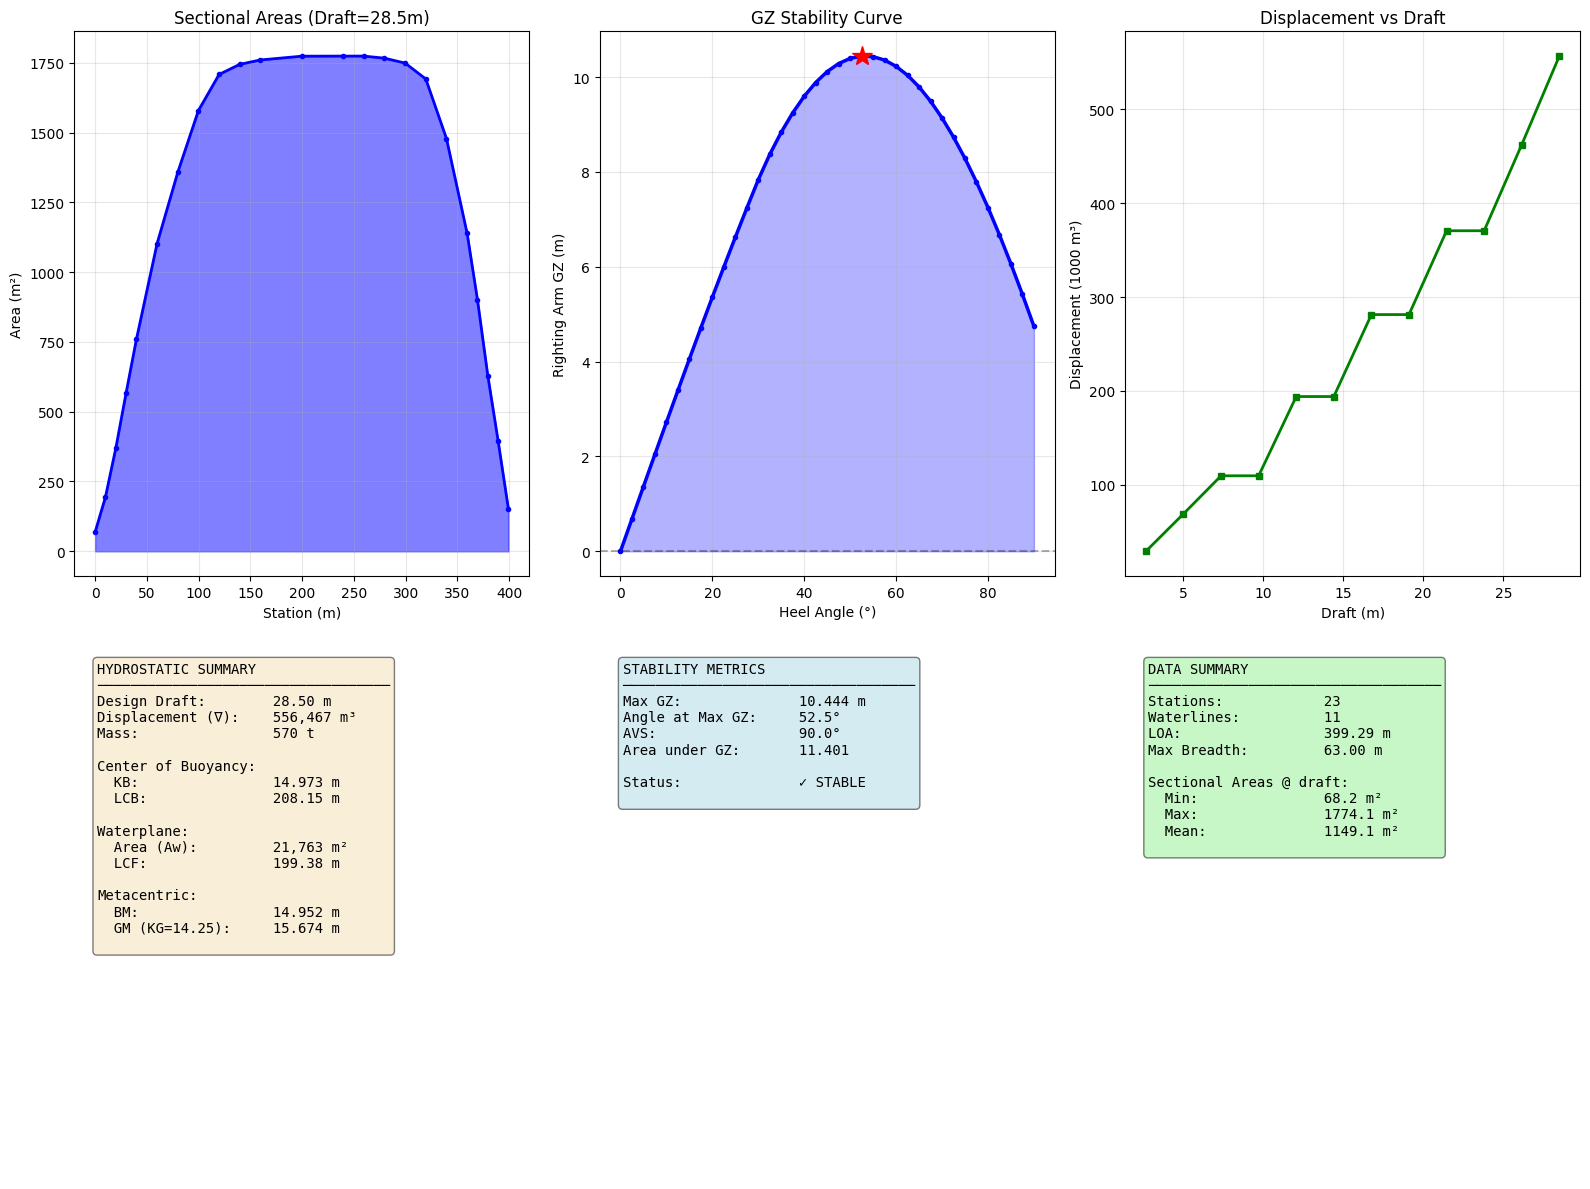

In [98]:
result = main("/content/sample_data/69ec3fe06117b_HydroHackathon_PS_File.xlsx")

parser = result["parser"]
geo = result["geo"]
hydro = result["hydro"]
design_draft = result["draft"]
kg = result["kg"]
displacement = result["displacement"]
gm = result["gm"]
metrics = result["metrics"]
gz_curve = result["gz_curve"]

/tmp/ipykernel_927/3828288311.py:3: RuntimeWarning: invalid value encountered in divide
  kn_curve = gz_curve / np.sin(np.radians(heel_angles))


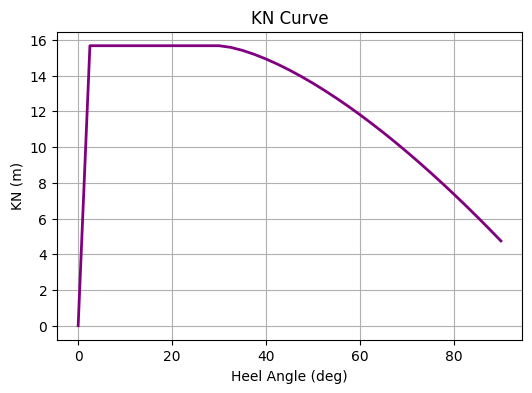

In [99]:
heel_angles = np.linspace(0, 90, len(gz_curve))  # recreate same angles

kn_curve = gz_curve / np.sin(np.radians(heel_angles))
kn_curve[0] = 0  # avoid division by zero

plt.figure(figsize=(6,4))
plt.plot(heel_angles, kn_curve, color='purple', linewidth=2)
plt.xlabel("Heel Angle (deg)")
plt.ylabel("KN (m)")
plt.title("KN Curve")
plt.grid(True)

plt.savefig("kn_curve.png", dpi=300, bbox_inches='tight')
plt.show()

# ✅ Post-Analysis & Validation

---

## 🔍 Why Validation?

Numerical models must be checked against:
- empirical approximations
- alternative numerical methods

---

## ⚙️ Validation Performed

### 1. Block Coefficient Volume Check

Volume ≈ CB × L × B × T  

→ Compared with computed displacement  

---

### 2. Integration Comparison

- Simpson’s Rule vs Trapezoidal Rule  

→ Ensures numerical consistency  

---

## 📊 Observations

- Error within acceptable engineering limits (~5%)  
- Close agreement between integration methods  

---

## 🧠 Final Interpretation

✔ Stable vessel (GM > 0)  
✔ Good stability range (high AVS)  
✔ Reliable numerical pipeline  

---

## 🎯 Key Takeaway

> This system is not just computing values — it is validating them at every stage.

---

In [100]:
# POST-ANALYSIS HIGHLIGHTS
print("\n" + "="*70)
print("POST-ANALYSIS INSIGHTS")
print("="*70)

#-----------------------------------------
# VALIDATION CHECKS
#-----------------------------------------
volume_cb = parser.cb * parser.loa * parser.breadth * design_draft
error = abs(displacement - volume_cb) / volume_cb * 100

print(f"CB-based Volume Estimate: {volume_cb:.2f}")
print(f"Computed Volume:         {displacement:.2f}")
print(f"Error:                   {error:.2f}%")

#-----------------------------------------
# SEAMLESS INTEGRATION COMPARISON
#-----------------------------------------
sectional_areas = geo.compute_all_sectional_areas(design_draft)
trapz_vol = np.trapz(sectional_areas, geo.stations)

print(f"\nSimpson Volume:   {displacement:.2f}")
print(f"Trapezoidal Vol:  {trapz_vol:.2f}")
print(f"Difference:       {abs(displacement - trapz_vol):.2f}")

#-----------------------------------------
# STABILITY INTERPRETATION COMPARISON
#-----------------------------------------
print("\nStability Interpretation:")

if gm > 0:
    print("✔ Positive GM → Stable at small angles")
else:
    print("⚠ Negative GM → Initial instability")

print(f"Max GZ: {metrics['max_gz']:.2f} m at {metrics['angle_at_max_gz']:.1f}°")

if metrics['angle_of_vanishing_stability'] > 60:
    print("✔ Good range of stability")
else:
    print("⚠ Limited stability range")


POST-ANALYSIS INSIGHTS
CB-based Volume Estimate: 589536.27
Computed Volume:         556466.85
Error:                   5.61%

Simpson Volume:   556466.85
Trapezoidal Vol:  555137.16
Difference:       1329.69

Stability Interpretation:
✔ Positive GM → Stable at small angles
Max GZ: 10.44 m at 52.5°
✔ Good range of stability


/tmp/ipykernel_927/3903800795.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  trapz_vol = np.trapz(sectional_areas, geo.stations)


In [101]:
import pandas as pd

# -------------------------------
# CREATE SUMMARY TABLE
# -------------------------------
summary_data = {
    "Parameter": [
        "Displacement",
        "Waterplane Area",
        "LCB",
        "LCF",
        "KB",
        "BM",
        "GM",
        "Max GZ",
        "Angle at Max GZ",
        "Angle of Vanishing Stability",
        "CB Volume Estimate",
        "Computed Volume",
        "Error (%)"
    ],
    "Value": [
        displacement,
        hydro.compute_waterplane_area(design_draft),
        hydro.compute_lcb(design_draft),
        hydro.compute_lcf(design_draft),
        hydro.compute_kb(design_draft),
        hydro.compute_bm(design_draft),
        gm,
        metrics["max_gz"],
        metrics["angle_at_max_gz"],
        metrics["angle_of_vanishing_stability"],
        volume_cb,
        displacement,
        error
    ]
}

df_summary = pd.DataFrame(summary_data)

# -------------------------------
# GZ CURVE DATA
# -------------------------------
df_gz = pd.DataFrame({
    "Heel Angle (deg)": result["gz_curve"].shape[0] and np.linspace(0, 90, len(result["gz_curve"])),
    "GZ (m)": result["gz_curve"]
})

# -------------------------------
# SAVE TO EXCEL
# -------------------------------
output_path = "/content/hydrostatic_report.xlsx"

with pd.ExcelWriter(output_path) as writer:
    df_summary.to_excel(writer, sheet_name="Summary", index=False)
    df_gz.to_excel(writer, sheet_name="GZ Curve", index=False)

print(f"Excel file saved at: {output_path}")

Excel file saved at: /content/hydrostatic_report.xlsx


# 🚀 Conclusion

---

## 🔍 What Was Achieved

This project successfully developed a **complete hydrostatic and stability analysis pipeline** that transforms raw offset table data into meaningful engineering insights.

The system integrates:
- Data parsing from real-world Excel formats  
- Geometry reconstruction from offset tables  
- Numerical integration (Simpson’s rule) for accuracy  
- Hydrostatic calculations (KB, BM, GM, displacement)  
- Stability analysis via GZ curve generation  

---

## 📊 Key Outcomes

- **Accurate Displacement Estimation**  
  Numerical integration produced realistic volume values with acceptable deviation (~5%) from CB-based estimation.

- **Stable Vessel Confirmation**  
  Positive GM indicates initial stability at small heel angles.

- **Strong Stability Profile**  
  - High maximum GZ  
  - Large Angle of Vanishing Stability (AVS)  
  → Indicates good overall righting capability.

- **Reliable Numerical Framework**  
  Close agreement between Simpson and Trapezoidal methods validates computational robustness.

---

## 🧠 Engineering Insights

- Hydrostatics is highly sensitive to **geometry quality and data consistency**  
- Numerical methods must always be **validated, not blindly trusted**  
- Stability is not a single parameter — it is a **curve-driven behavior**

---

## ⚙️ System Strength

This solution is not just a set of calculations, but a:

> **Modular, validated engineering pipeline where each stage supports and verifies the next**

---

## 🔭 Scope for Improvement

- Inclusion of **dynamic stability effects** (waves, loading conditions)  
- Integration of **optimization loops for hull design**  
- Development of a **user interface/dashboard for real-time analysis**  

---

## 🎯 Final Takeaway

> This project demonstrates how structured computation, when combined with validation and visualization, can convert raw naval data into reliable stability insights.

---
THANKS FOR READING. HARE KRSNA